Download data

Thông tin giá cổ phiếu của APPLE

Xử lý:
- Đưa Date từ index thành cột
- Làm phẳng cột nếu bị MultiIndex
- Giữ đầy đủ các cột


In [ ]:
import yfinance as yf

df = yf.download(
    "AAPL",
    start="2000-01-01",
    end="2025-12-26",
    interval="1d",
    auto_adjust=False
)

df.reset_index(inplace=True)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']]

df.to_csv("AAPL_historical_2000_2025.csv", index=False)

print(df.head())


[*********************100%***********************]  1 of 1 completed


        Date      Open      High       Low     Close  Adj Close     Volume
0 2000-01-03  0.936384  1.004464  0.907924  0.999442   0.839281  535796800
1 2000-01-04  0.966518  0.987723  0.903460  0.915179   0.768521  512377600
2 2000-01-05  0.926339  0.987165  0.919643  0.928571   0.779767  778321600
3 2000-01-06  0.947545  0.955357  0.848214  0.848214   0.712287  767972800
4 2000-01-07  0.861607  0.901786  0.852679  0.888393   0.746027  460734400


Download data

Thông tin biến động thị trường toàn thế giới VIX (Volatility Index)

Xử lý:
- Đưa Date từ index thành cột
- Làm phẳng cột nếu bị MultiIndex
- Đổi tên Close thành VIX

In [ ]:
import yfinance as yf

df = yf.download(
    "^VIX",
    start="2000-01-01",
    end="2025-12-26",
    interval="1d"
)

df.reset_index(inplace=True)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df = df[['Date', 'Close']]

df.rename(columns={'Close': 'VIX'}, inplace=True)

df.to_csv("VIX_2000_2025.csv", index=False)

print(df.head())


/tmp/ipython-input-678810053.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

        Date        VIX
0 2000-01-03  24.209999
1 2000-01-04  27.010000
2 2000-01-05  26.410000
3 2000-01-06  25.730000
4 2000-01-07  21.719999


Download data

Thông tin biến động cổ phiếu trong ngành công nghệ (Nasdaq Index)

Xử lý:
- Đưa Date từ index thành cột
- Làm phẳng cột nếu bị MultiIndex
- Đổi tên Close thành NASDAQ

In [ ]:
import yfinance as yf

df = yf.download(
    "^IXIC",
    start="2000-01-01",
    end="2025-12-26",
    interval="1d"
)

df.reset_index(inplace=True)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df = df[['Date', 'Close']]

df.rename(columns={'Close': 'NASDAQ'}, inplace=True)

df.to_csv("NASDAQ_2000_2025.csv", index=False)

print(df.head())


/tmp/ipython-input-1892225825.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


        Date       NASDAQ
0 2000-01-03  4131.149902
1 2000-01-04  3901.689941
2 2000-01-05  3877.540039
3 2000-01-06  3727.129883
4 2000-01-07  3882.620117


Download data

Thông tin một chỉ số lãi suất trái phiếu chính phủ Mỹ (TNX)

Xử lý:

* Đưa Date từ index thành cột

* Làm phẳng cột nếu bị MultiIndex

* Đổi tên Close thành TNX



In [ ]:
import yfinance as yf

df = yf.download(
    "^TNX",
    start="2000-01-01",
    end="2025-12-26",
    interval="1d"
)

df.reset_index(inplace=True)

df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

df = df[['Date', 'Close']]

df.rename(columns={'Close': 'TNX'}, inplace=True)

df.to_csv("TNX_2000_2025.csv", index=False)

print(df.head())


/tmp/ipython-input-1625452884.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


        Date    TNX
0 2000-01-03  6.548
1 2000-01-04  6.485
2 2000-01-05  6.599
3 2000-01-06  6.549
4 2000-01-07  6.504


- Merge các tập dữ liệu AAPL, VIX, NASDAQ, TNX lại theo cột Date
- Chuyển Date sang datetime & sắp xếp theo thời gian

In [ ]:
import pandas as pd

aapl = pd.read_csv("AAPL_historical_2000_2025.csv")
vix = pd.read_csv("VIX_2000_2025.csv")
nasdaq = pd.read_csv("NASDAQ_2000_2025.csv")
tnx = pd.read_csv("TNX_2000_2025.csv")

for df in [aapl, vix, nasdaq, tnx]:
    df["Date"] = pd.to_datetime(df["Date"])

data = aapl.merge(vix, on="Date", how="left")
data = data.merge(nasdaq, on="Date", how="left")
data = data.merge(tnx, on="Date", how="left")

data = data.sort_values("Date").reset_index(drop=True)

data.to_csv("data_2000_2025.csv", index=False)

print(data.head())
print(data.tail())


        Date      Open      High       Low     Close  Adj Close     Volume  \
0 2000-01-03  0.936384  1.004464  0.907924  0.999442   0.839281  535796800   
1 2000-01-04  0.966518  0.987723  0.903460  0.915179   0.768521  512377600   
2 2000-01-05  0.926339  0.987165  0.919643  0.928571   0.779767  778321600   
3 2000-01-06  0.947545  0.955357  0.848214  0.848214   0.712287  767972800   
4 2000-01-07  0.861607  0.901786  0.852679  0.888393   0.746027  460734400   

         VIX       NASDAQ    TNX  
0  24.209999  4131.149902  6.548  
1  27.010000  3901.689941  6.485  
2  26.410000  3877.540039  6.599  
3  25.730000  3727.129883  6.549  
4  21.719999  3882.620117  6.504  
           Date        Open        High         Low       Close   Adj Close  \
6530 2025-12-18  273.609985  273.630005  266.950012  272.190002  272.190002   
6531 2025-12-19  272.149994  274.600006  269.899994  273.670013  273.670013   
6532 2025-12-22  272.859985  273.880005  270.510010  270.970001  270.970001   
6533 

Xử lý data:
- Sắp xếp theo Date để đảm bảo thứ tự thời gian
- Kiểm tra giá trị null của từng cột
- Xử lý giá trị TNX bị thiếu bằng cách điền forward fill hoặc backward fill
- Làm tròn số thập phân cho các cột giá và chỉ số (đến 2 chữ số thập phân)
- Kiểm tra outliers (sử dụng IQR cho cột Close). Tuy nhiên, không loại bỏ outliers ở đây vì dữ liệu chứng khoán có thể có biến động lớn do Khủng hoảng tài chính, Tin tức lớn (earnings, chiến tranh, lãi suất), Biến động thị trường mạnh.




In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

df = pd.read_csv('data_2000_2025.csv')

print("Kích thước dữ liệu gốc:", df.shape)
print("\nThông tin dữ liệu:")
print(df.info())
print("\nGiá trị thiếu ban đầu:")
print(df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

df['TNX'] = df['TNX'].ffill()
df['TNX'] = df['TNX'].bfill()

columns_to_round = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'VIX', 'NASDAQ', 'TNX']
for col in columns_to_round:
    if col in df.columns:
        df[col] = df[col].round(2)

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

close_outliers = detect_outliers_iqr(df['Close'])
print(f"\nSố lượng outliers trong Close: {len(close_outliers)}")
if len(close_outliers) > 0:
    print("Một số outliers mẫu:\n", close_outliers.head())

print("\nGiá trị thiếu sau khi làm sạch:")
print(df.isnull().sum())

df.to_csv('data_cleaned_2000_2025.csv', index=False)

print("\nĐã lưu dữ liệu sạch vào file: data_cleaned_2000_2025.csv")
print("Kích thước dữ liệu sau khi làm sạch:", df.shape)


Kích thước dữ liệu gốc: (6535, 10)

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6535 entries, 0 to 6534
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6535 non-null   object 
 1   Open       6535 non-null   float64
 2   High       6535 non-null   float64
 3   Low        6535 non-null   float64
 4   Close      6535 non-null   float64
 5   Adj Close  6535 non-null   float64
 6   Volume     6535 non-null   int64  
 7   VIX        6535 non-null   float64
 8   NASDAQ     6535 non-null   float64
 9   TNX        6529 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 510.7+ KB
None

Giá trị thiếu ban đầu:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
VIX          0
NASDAQ       0
TNX          6
dtype: int64

Số lượng outliers trong Close: 1178
Một số outliers mẫu:
 5199    134.18
5200    131.40
5277    131.8

Visualization

Vẽ 2 biểu đồ:
  + Xu hướng giá của Apple
  + Kiểm tra tương quan giữa giá cổ phiếu Apple với VIX, Nadaq và TNX




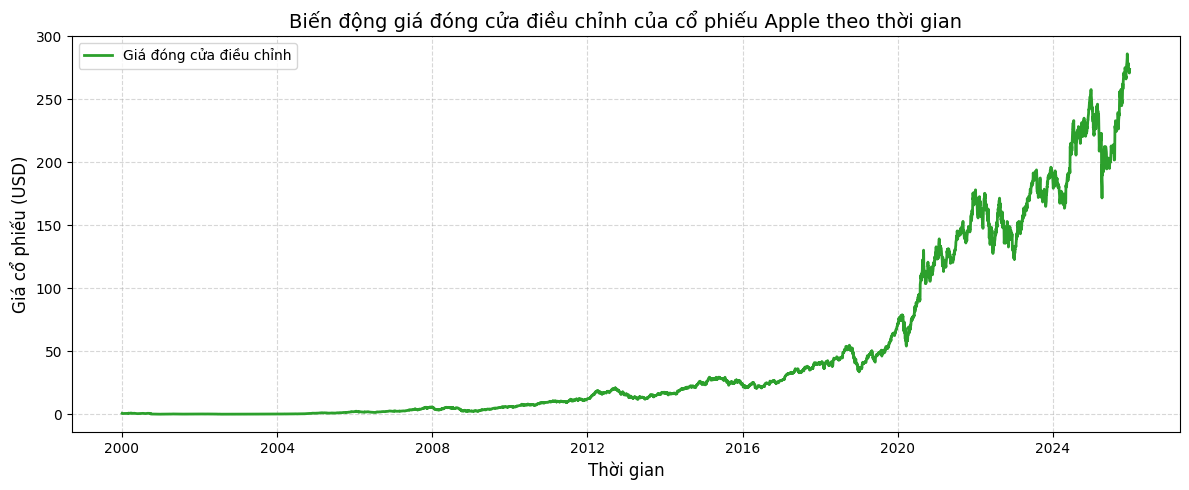

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    df['Date'],
    df['Adj Close'],
    linewidth=2,
    color='tab:green',
    label='Giá đóng cửa điều chỉnh'
)

plt.title("Biến động giá đóng cửa điều chỉnh của cổ phiếu Apple theo thời gian", fontsize=14)
plt.xlabel("Thời gian", fontsize=12)
plt.ylabel("Giá cổ phiếu (USD)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Nhận xét:

- Giá cổ phiếu Apple có xu hướng tăng mạnh trong dài hạn (2000–2025).
- Giai đoạn đầu biến động thấp, tăng trưởng chậm; từ sau 2019 giá tăng nhanh và dao động mạnh hơn.
- Biến động lớn phản ánh tác động của các sự kiện kinh tế – tài chính quan trọng.
- Chuỗi giá thể hiện rõ tính xu hướng và phụ thuộc theo thời gian, phù hợp cho bài toán dự đoán giá cổ phiếu.

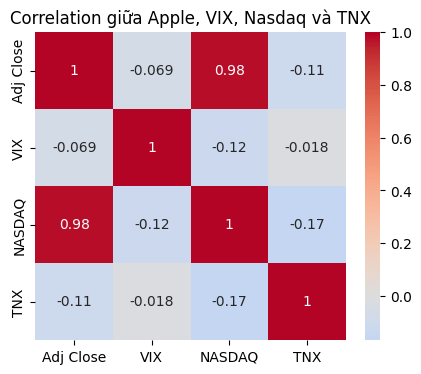

In [ ]:
import seaborn as sns

corr = df[['Adj Close', 'VIX', 'NASDAQ','TNX']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation giữa Apple, VIX, Nasdaq và TNX")
plt.show()

Nhận xét:

- Apple – Nasdaq (≈ 0.98): Tương quan dương rất mạnh, cho thấy giá cổ phiếu Apple biến động gần như đồng pha với chỉ số Nasdaq, phản ánh xu hướng chung của nhóm công nghệ.

- Apple – VIX (≈ -0.07): Tương quan âm nhưng rất yếu, cho thấy khi mức độ sợ hãi thị trường tăng, giá Apple có xu hướng giảm nhẹ nhưng mối quan hệ không rõ ràng.

- Apple – TNX (≈ -0.11): Tương quan âm yếu, cho thấy lãi suất trái phiếu Mỹ có ảnh hưởng nhất định nhưng không mạnh đến giá Apple.

- VIX, TNX với Nasdaq: Đều có tương quan âm yếu, phản ánh vai trò của VIX và TNX chủ yếu trong việc đo rủi ro và điều kiện vĩ mô hơn là dẫn dắt trực tiếp giá cổ phiếu.

-> Nasdaq là biến đại diện tốt cho xu hướng giá Apple, trong khi VIX và TNX phù hợp để phân tích rủi ro và bối cảnh thị trường.

Feature Engineering
- Return (tỷ suất sinh lợi):
    + Đo mức thay đổi tương đối của giá, thay vì giá tuyệt đối
    + Công thức:

    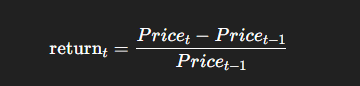
- Lag:
  + giá trị trong quá khứ của biến, dùng làm đầu vào để dự đoán
  + VD. lag_1: giá ngày hôm qua, lag_5: giá 5 ngày trước,..
  + Lag features được sử dụng để cung cấp thông tin lịch sử của chuỗi giá, giúp mô hình học được mối quan hệ phụ thuộc theo thời gian giữa các quan sát.
- Moving Average(đường trung bình trượt):
  + Là giá trung bình của n ngày gần nhất, trượt theo thời gian.
  + Công thức:

  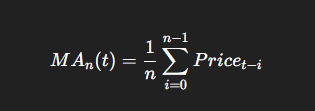
- Volatility(độ biến động):
    + Đo mức độ dao động của giá, phản ánh rủi ro.
    + Công thức:

    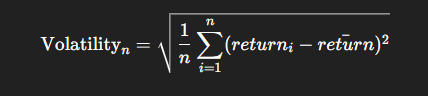

In [ ]:
for lag in [1, 5, 10]:
    df[f'lag_{lag}'] = df['Adj Close'].shift(lag)

df['return'] = df['Adj Close'].pct_change()

df['volatility_5'] = df['return'].rolling(5).std()
df['volatility_10'] = df['return'].rolling(10).std()

df['ma_5'] = df['Adj Close'].rolling(5).mean()
df['ma_20'] = df['Adj Close'].rolling(20).mean()


RSI (Relative Strength Index)

- Đo mức độ quá mua / quá bán

- Giá trị nằm trong [0, 100]

- Công thức:

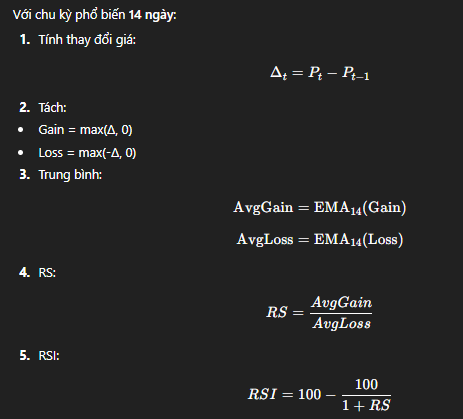

-> RSI được tính toán hoàn toàn từ công thức toán học dựa trên biến động giá trong quá khứ, giúp phản ánh trạng thái quá mua hoặc quá bán của thị trường.

MACD (Moving Average Convergence Divergence)

- Đo động lượng xu hướng (momentum)

- Dựa trên đường trung bình động hàm mũ (EMA)
    + EMA = trung bình giá có “trọng số giảm dần theo thời gian”

        + Giá mới nhất → trọng số lớn nhất

        + Giá càng cũ → ảnh hưởng càng nhỏ

        + Dùng để: Xác định xu hướng, phát hiện đảo chiều sớm
        + Công thức:

        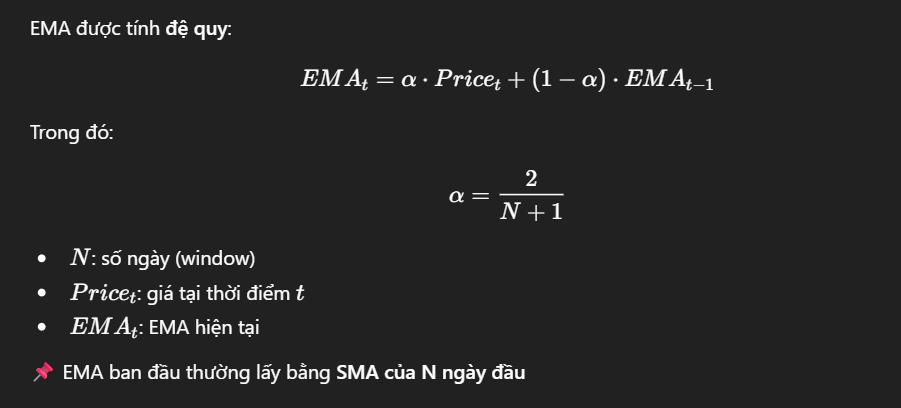

- Công thức:

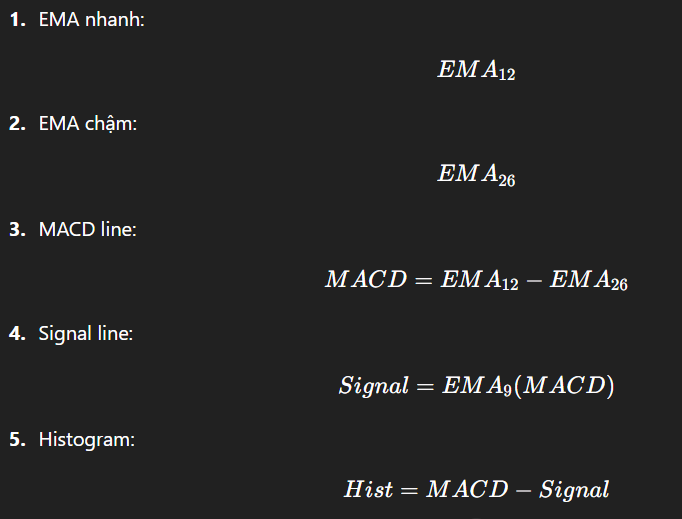



In [ ]:
def compute_rsi(series, window=14):
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist


In [ ]:
df['RSI_14'] = compute_rsi(df['Adj Close'], window=14)

df['MACD'], df['MACD_signal'], df['MACD_hist'] = compute_macd(df['Adj Close'])


Các đặc trưng lag, return và rolling window tạo ra giá trị thiếu ở các quan sát đầu tiên. Những dòng này được loại bỏ để đảm bảo dữ liệu đầu vào đầy đủ cho phân tích và mô hình hóa.

In [ ]:
df_fe = df.dropna().reset_index(drop=True)
print(df_fe.shape)
df_fe.head()


(6516, 22)


,Date,Open,High,Low,Close,Adj Close,Volume,VIX,NASDAQ,TNX,...,lag_10,return,volatility_5,volatility_10,ma_5,ma_20,RSI_14,MACD,MACD_signal,MACD_hist
0,2000-01-31,0.90,0.93,0.84,0.93,0.78,701680000,24.95,3940.35,6.67,...,0.75,0.026316,0.046762,0.042986,0.806,0.7750,55.319149,-0.002278,-0.006032,0.003754
1,2000-02-01,0.93,0.94,0.89,0.90,0.75,318035200,23.45,4051.98,6.62,...,0.78,-0.038462,0.036826,0.043001,0.788,0.7705,55.319149,-0.005610,-0.005947,0.000337
2,2000-02-02,0.90,0.91,0.87,0.88,0.74,464195200,23.12,4073.96,6.60,...,0.80,-0.013333,0.036735,0.041859,0.770,0.7690,60.465116,-0.008955,-0.006549,-0.002406
3,2000-02-03,0.90,0.93,0.90,0.92,0.77,475193600,22.01,4210.98,6.47,...,0.85,0.040541,0.046561,0.038228,0.760,0.7685,55.263158,-0.009080,-0.007055,-0.002025
4,2000-02-04,0.93,0.98,0.93,0.96,0.81,425320000,21.54,4244.14,6.52,...,0.83,0.051948,0.038058,0.042312,0.770,0.7735,57.500000,-0.005883,-0.006821,0.000937


Phân tích correlation giữa các engineered features

                 return      Open      High       Low     lag_1     lag_5  \
return         1.000000 -0.006678 -0.004040 -0.003753 -0.010059 -0.009437   
Open          -0.006678  1.000000  0.999921  0.999927  0.999772  0.998833   
High          -0.004040  0.999921  1.000000  0.999897  0.999724  0.998881   
Low           -0.003753  0.999927  0.999897  1.000000  0.999716  0.998716   
lag_1         -0.010059  0.999772  0.999724  0.999716  1.000000  0.999080   
lag_5         -0.009437  0.998833  0.998881  0.998716  0.999080  1.000000   
lag_10        -0.009312  0.997864  0.997958  0.997711  0.998117  0.998866   
ma_5          -0.008085  0.999658  0.999663  0.999610  0.999863  0.999497   
ma_20         -0.008893  0.998717  0.998800  0.998589  0.998959  0.999429   
volatility_5  -0.039531 -0.236296 -0.234450 -0.237793 -0.230487 -0.228256   
volatility_10 -0.052007 -0.268983 -0.267408 -0.270345 -0.262280 -0.260900   
RSI_14         0.228595  0.015333  0.015172  0.017360  0.013009  0.001280   

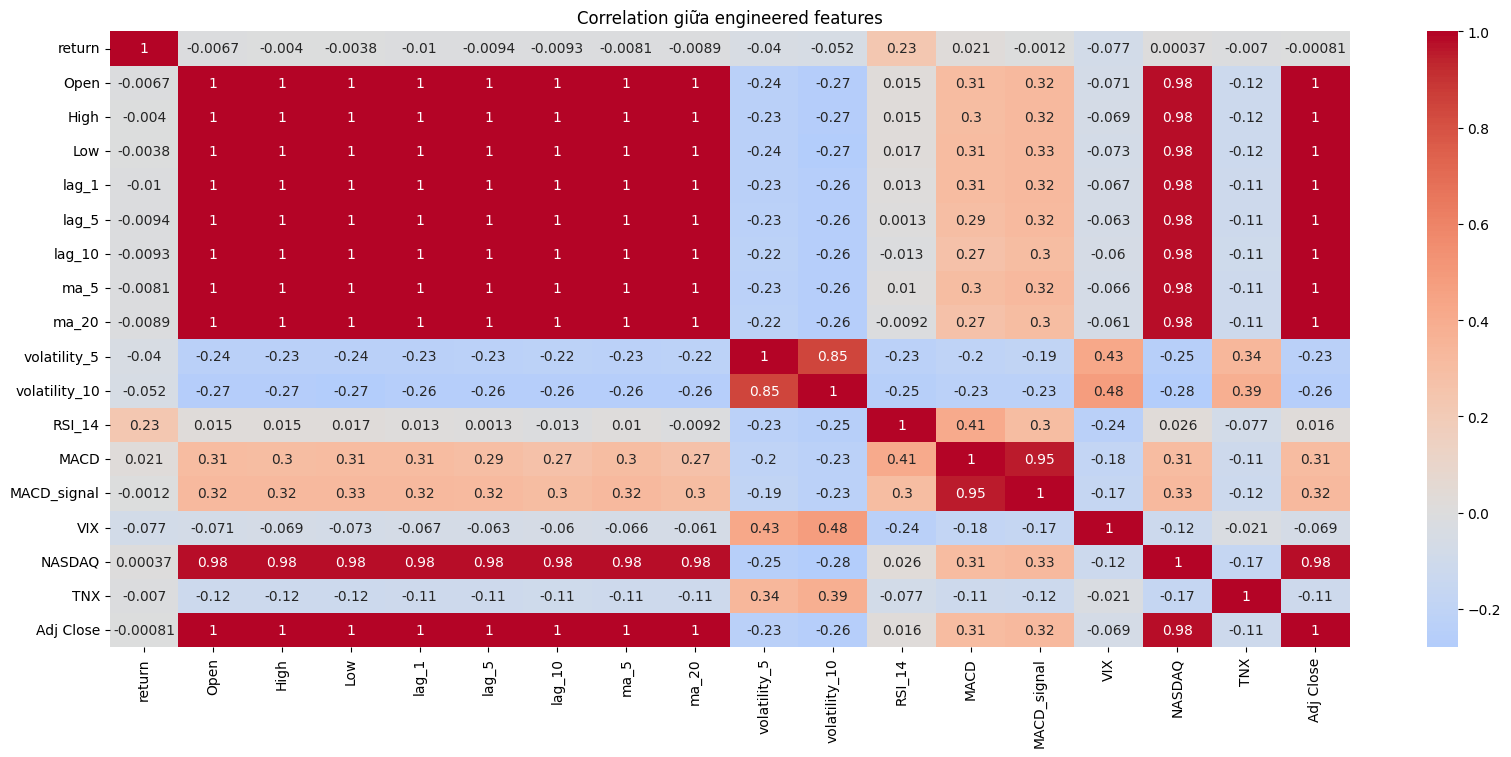

In [ ]:
features = [
    'return','Open', 'High', 'Low',
    'lag_1', 'lag_5', 'lag_10',
    'ma_5', 'ma_20',
    'volatility_5', 'volatility_10',
    'RSI_14',
    'MACD', 'MACD_signal',
    'VIX', 'NASDAQ', 'TNX','Adj Close'
]

corr = df_fe[features].corr()
print(corr)

plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation giữa engineered features")
plt.show()


Nhận xét:

- Các đặc trưng giá (Adj Close, lag, moving average) có tương quan rất cao (~0.98–1) → tồn tại đa cộng tuyến mạnh, không nên dùng đồng thời tất cả trong mô hình.

- Return gần như không tương quan với các biến giá → phản ánh biến động ngắn hạn độc lập với mức giá tuyệt đối.

- Volatility (5,10) tương quan cao với nhau và có tương quan dương với VIX, cho thấy VIX phản ánh tốt mức độ rủi ro thị trường.

- NASDAQ có tương quan rất cao với giá Apple → ảnh hưởng mạnh của xu hướng thị trường chung đến cổ phiếu Apple.

- TNX (lợi suất trái phiếu Mỹ) có tương quan âm nhẹ với giá cổ phiếu và tương quan dương nhẹ với volatility, phản ánh tác động gián tiếp của chính sách tiền tệ và lãi suất đến thị trường chứng khoán, dù mức ảnh hưởng không quá mạnh trong dữ liệu này.

- RSI_14 có tương quan dương nhẹ với return và tương quan yếu với các biến giá, cho thấy RSI chủ yếu phản ánh động lượng (momentum) ngắn hạn thay vì mức giá tuyệt đối. Điều này giúp RSI trở thành đặc trưng bổ sung hữu ích, ít bị đa cộng tuyến với các biến giá.

- MACD và MACD_signal có tương quan rất cao với nhau (≈ 0.95), cho thấy hai biến này mang thông tin gần như trùng lặp. Vì vậy, trong thực tế chỉ nên giữ một trong hai (hoặc sử dụng MACD histogram) để giảm đa cộng tuyến.

- MACD và MACD_signal có tương quan mức trung bình với các biến giá và Nasdaq, phản ánh khả năng nắm bắt xu hướng trung hạn của thị trường, bổ sung thông tin khác với các đặc trưng lag và moving average thuần túy.

- Các biến volatility có tương quan âm với các chỉ báo động lượng (RSI, MACD), cho thấy khi thị trường biến động mạnh thì tín hiệu xu hướng thường kém ổn định hơn — một đặc điểm phổ biến trong dữ liệu tài chính.

-> Nhiều hệ số tương quan xấp xỉ 1 xuất hiện do các đặc trưng lag và moving average đều được xây dựng từ cùng chuỗi giá cổ phiếu Apple, dẫn đến hiện tượng đa cộng tuyến mạnh. Điều này phản ánh xu hướng dài hạn của giá cổ phiếu hơn là thông tin biến động mới, do đó cần chọn lọc đặc trưng trước khi huấn luyện mô hình.

Chia tập Train / Validation / Test và chuẩn hóa tập dữ liệu Train

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

target = 'Adj Close'
features = [
    'return',
    'lag_1', 'lag_5', 'lag_10',
    'ma_5', 'ma_20',
    'volatility_5', 'volatility_10',
    'RSI_14',
    'MACD', 'MACD_signal',
    'VIX', 'NASDAQ', 'TNX'
]

X = df_fe[features]
y = df_fe[target]

n = len(df_fe)

train_size = int(n * 0.7)
val_size   = int(n * 0.15)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]

X_val = X.iloc[train_size:train_size + val_size]
y_val = y.iloc[train_size:train_size + val_size]

X_test = X.iloc[train_size + val_size:]
y_test = y.iloc[train_size + val_size:]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_val_scaled   = pd.DataFrame(X_val_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=features)


Train size: (4561, 14)
Validation size: (977, 14)
Test size: (978, 14)


Xuất các tập dữ liệu ra file csv

In [ ]:
df_fe.to_csv("raw_data.csv", index=False)

Dữ liệu chưa scale

In [ ]:
train_raw = X_train.copy()
train_raw[target] = y_train.values

val_raw = X_val.copy()
val_raw[target] = y_val.values

test_raw = X_test.copy()
test_raw[target] = y_test.values

train_raw.to_csv("train_data_raw.csv", index=False)
val_raw.to_csv("val_data_raw.csv", index=False)
test_raw.to_csv("test_data_raw.csv", index=False)



Dữ liệu đã scale

In [ ]:
train_scaled = X_train_scaled.copy()
train_scaled[target] = y_train.values

val_scaled = X_val_scaled.copy()
val_scaled[target] = y_val.values

test_scaled = X_test_scaled.copy()
test_scaled[target] = y_test.values

train_scaled.to_csv("train_data_scaled.csv", index=False)
val_scaled.to_csv("val_data_scaled.csv", index=False)
test_scaled.to_csv("test_data_scaled.csv", index=False)
